# Aufgabe 1

In [1]:
speed = 50 * 10**(-9)
size1 = 100 * 10**(9)
size1_2 = 100 * 2**(30)
size2 = 100 * 10**(12)
size2_2 = 100 * 2**(40)
size3 = 100 * 10**(15)
size3_2 = 100 * 2**(50)

In [2]:
print(str(speed * size1))
print(str(speed * size2))
print(str(speed * size3))

5000.0
5000000.0
5000000000.0


In [3]:
print(str(speed * 30))
print(str(speed * 40))
print(str(speed * 50))

1.5e-06
2.0000000000000003e-06
2.5e-06


# Aufgabe 2

In [4]:
import graphviz

class BTree: 
    def __init__(self, key, ltree=None, rtree=None, val=None):
        self.key = key
        self.l = ltree
        self.r = rtree
        self.val = val
        
    def insert(self, k, v):
        if k<self.key: 
            if self.l: 
                self.l.insert(k,v)
            else:
                self.l = BTree(k, val=v)
                
        elif k>self.key: 
            if self.r: 
                self.r.insert(k,v)
            else:
                self.r = BTree(k, val=v)

        elif k==self.key: 
            self.val = v
        
    def search(self, key): 
        if key<self.key:
            if self.l:
                return self.l.search(key)
            else:
                return None
        elif key>self.key:
            if self.r: 
                return self.r.search(key)
            else: 
                return None
        elif key==self.key: 
            return self.val

    def deleteND(self, k):
        if self.key == k: 
            if not self.l and not self.r:
                return None
            elif not self.l:
                return self.r
            elif not self.r: 
                return self.l
            else: 
                m = self.r.minEl()
                return BTree(m.key, self.l, self.r.deleteND(m.key), m.val)
        else: 
            if k<self.key:
                return BTree(self.key, self.l.deleteND(k), self.r, self.val)
            elif k>self.key: 
                return BTree(self.key, self.l, self.r.deleteND(k), self.val)
        
    def edges(self):         
        if self.l:
            edges_l = [(str(self.key) , str(self.l.key))] + self.l.edges()
        else: 
            edges_l = []
            
        if self.r:
            edges_r = [(str(self.key) , str(self.r.key))] + self.r.edges()
        else: 
            edges_r = []
        
        return edges_l + edges_r

    # def minEl(self):
    #     ret = self
    #     if self.l:
    #         ret = self.l.minEl()
    #     return ret

    # def maxEl(self):
    #     ret = self
    #     if self.r:
    #         ret = self.r.maxEl()
    #     return ret

    def minEl(self):
        while self.l:
            self = self.l
        return self

    def maxEl(self):
        while self.r:
            self = self.r
        return self

    def plot(self): 
        g  = graphviz.Graph()
        g.edges(self.edges())
        return g

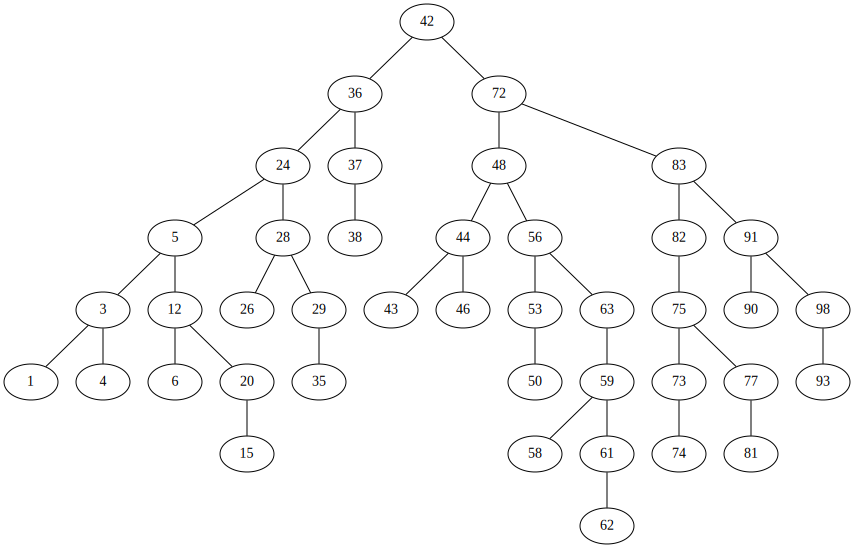

In [5]:
from random import sample
t = BTree(42, val="9")

for x in sample(range(100), 40): 
    t.insert(x,"x")

t.plot()

In [6]:
t.minEl().key

1

In [8]:
t.maxEl().key

98

# Aufgabe 4

In [18]:
import graphviz

class BTree: 
    def __init__(self, key, ltree=None, rtree=None, val=None, parent=None):
        self.key = key
        self.l = ltree
        self.r = rtree
        self.val = val
        self.parent = parent
        if self.l:
            self.l.parent = self
        if self.r:
            self.r.parent = self
        
    def insert(self, k, v):
        if k<self.key: 
            if self.l: 
                self.l.insert(k,v)
            else:
                self.l = BTree(k, val=v, parent=self)
        elif k>self.key: 
            if self.r: 
                self.r.insert(k,v)
            else:
                self.r = BTree(k, val=v, parent=self)
        elif k==self.key: 
            self.val = v
        
    def search(self, key): 
        if key<self.key:
            if self.l:
                return self.l.search(key)
            else:
                return None
        elif key>self.key:
            if self.r: 
                return self.r.search(key)
            else: 
                return None
        elif key==self.key: 
            return self.val

    def deleteND(self, k):
        if self.key == k: 
            if not self.l and not self.r:
                return None
            elif not self.l:
                self.r.parent = self.parent
                return self.r
            elif not self.r:
                self.l.parent = self.parent
                return self.l
            else: 
                m = self.r.minEl()
                return BTree(m.key, self.l, self.r.deleteND(m.key), m.val, parent = self.parent)
        else: 
            if k<self.key:
                return BTree(self.key, self.l.deleteND(k), self.r, self.val, parent = self.parent)
            elif k>self.key: 
                return BTree(self.key, self.l, self.r.deleteND(k), self.val, parent = self.parent)

    def delete(self,k):
        if self.key == k:
            if not self.r and not self.l:
                if self == self.parent.l:
                    self.parent.l = None
                else:
                    self.parent.r = None
            elif not self.r:
                if self == self.parent.l:
                    self.parent.l = self.l
                else:
                    self.parent.r = self.l
            elif not self.l:
                if self == self.parent.l:
                    self.parent.l = self.r
                else:
                    self.parent.r = self.r
            else:
                m = self.r.minEl()
                self.key = m.key
                self.val = m.val
                self.r.delete(m.key)
        elif k < self.key:
            self.l.delete(k)
        else:
            self.r.delete(k)
        
    def edges(self):         
        if self.l:
            edges_l = [(str(self.key) , str(self.l.key))] + self.l.edges()
        else: 
            edges_l = []
            
        if self.r:
            edges_r = [(str(self.key) , str(self.r.key))] + self.r.edges()
        else: 
            edges_r = []
        
        return edges_l + edges_r

    def minEl(self):
        while self.l:
            self = self.l
        return self

    def maxEl(self):
        while self.r:
            self = self.r
        return self

    def plot(self): 
        g  = graphviz.Graph()
        g.edges(self.edges())
        return g

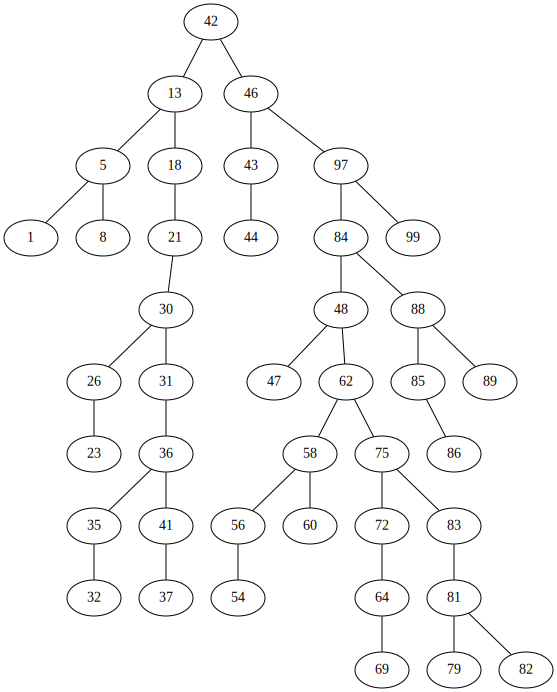

In [19]:
from random import sample
t = BTree(42, val="9")

for x in sample(range(100), 40): 
    t.insert(x,"x")

t.plot()

# Aufgabe 6

In [22]:
import graphviz

class BTree: 
    def __init__(self, key, ltree=None, rtree=None, val=None, parent=None):
        self.key = key
        self.l = ltree
        self.r = rtree
        self.val = val
        self.parent = parent
        if self.l:
            self.l.parent = self
        if self.r:
            self.r.parent = self
        
    def insert(self, k, v):
        if k<self.key: 
            if self.l: 
                self.l.insert(k,v)
            else:
                self.l = BTree(k, val=v, parent=self)
        elif k>self.key: 
            if self.r: 
                self.r.insert(k,v)
            else:
                self.r = BTree(k, val=v, parent=self)
        elif k==self.key: 
            self.val = v
        
    def search(self, key): 
        if key<self.key:
            if self.l:
                return self.l.search(key)
            else:
                return None
        elif key>self.key:
            if self.r: 
                return self.r.search(key)
            else: 
                return None
        elif key==self.key: 
            return self.val

    def deleteND(self, k):
        if self.key == k: 
            if not self.l and not self.r:
                return None
            elif not self.l:
                self.r.parent = self.parent
                return self.r
            elif not self.r:
                self.l.parent = self.parent
                return self.l
            else: 
                m = self.r.minEl()
                return BTree(m.key, self.l, self.r.deleteND(m.key), m.val, parent = self.parent)
        else: 
            if k<self.key:
                return BTree(self.key, self.l.deleteND(k), self.r, self.val, parent = self.parent)
            elif k>self.key: 
                return BTree(self.key, self.l, self.r.deleteND(k), self.val, parent = self.parent)

    def delete(self,k):
        if self.key == k:
            if not self.r and not self.l:
                if self == self.parent.l:
                    self.parent.l = None
                else:
                    self.parent.r = None
            elif not self.r:
                if self == self.parent.l:
                    self.parent.l = self.l
                else:
                    self.parent.r = self.l
            elif not self.l:
                if self == self.parent.l:
                    self.parent.l = self.r
                else:
                    self.parent.r = self.r
            else:
                m = self.r.minEl()
                self.key = m.key
                self.val = m.val
                self.r.delete(m.key)
        elif k < self.key:
            self.l.delete(k)
        else:
            self.r.delete(k)

    def depth(self):
        if not self.r and not self.l:
            return 1
        elif not self.r:
            return self.l.depth() + 1
        elif not self.l:
            return self.r.depth() + 1
        return max(self.l.depth(), self.r.depth()) + 1

    def __len__(self):
        if not self.r and not self.l:
            return 1
        elif not self.r:
            return len(self.l) + 1
        elif not self.l:
            return len(self.r) + 1
        return len(self.l) + len(self.r) + 1

    def keys(self):
        if not self.l and not self.r:
            return [self.key]
        elif not self.l:
            return self.r.keys() + [self.key]
        elif not self.r:
            return self.l.keys() + [self.key]
        return self.l.keys() + self.r.keys() + [self.key]

    def vals(self):
        if not self.l and not self.r:
            return [self.val]
        elif not self.l:
            return self.r.vals() + [self.val]
        elif not self.r:
            return self.l.vals() + [self.val]
        return self.l.vals() + self.r.vals() + [self.val]
        
    def edges(self):         
        if self.l:
            edges_l = [(str(self.key) , str(self.l.key))] + self.l.edges()
        else: 
            edges_l = []
            
        if self.r:
            edges_r = [(str(self.key) , str(self.r.key))] + self.r.edges()
        else: 
            edges_r = []
        
        return edges_l + edges_r

    def minEl(self):
        while self.l:
            self = self.l
        return self

    def maxEl(self):
        while self.r:
            self = self.r
        return self

    def plot(self): 
        g  = graphviz.Graph()
        g.edges(self.edges())
        return g

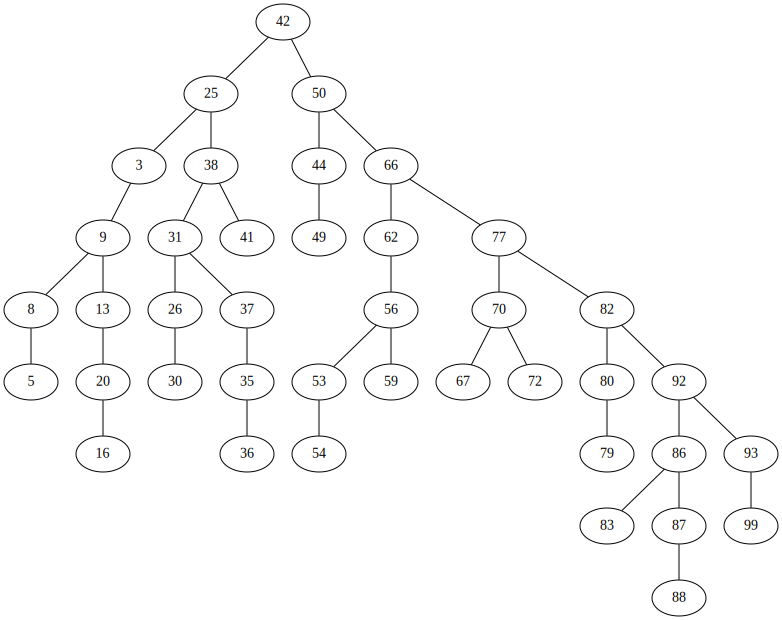

In [30]:
from random import sample
t = BTree(42, val=42)

for x in sample(range(100), 40): 
    t.insert(x,x)

t.plot()

In [31]:
t.depth()

9

In [32]:
len(t)

40

In [33]:
t.keys() == t.vals()

True